<a href="https://colab.research.google.com/github/SLCFLAB/Fintech2026-2/blob/main/DL09_generative_models/GEN_1_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 생성모델 1. VAE (Variational AutoEncoder)


| 순서 | 내용 |
|---|---|
| 0 | 생성모델 overview |
| 1 | AutoEncoder vs VAE: 구조와 loss |
| 2 | 두 모델 학습 (latent 2차원) |
| 3 | Latent space 비교, 생성, 보간 |
| 4 | 활용: 재구성 오차로 이상 탐지 |

- 전체 실행 시간: T4 GPU 기준 약 3분

Reference: https://github.com/Jackson-Kang/Pytorch-VAE-tutorial

## 0. 생성모델이란?

- 분류 모델: $p(y \mid x)$ 학습 → "이 이미지는 7이다"
- 생성 모델: $p(x)$ 자체를 학습 → "숫자 이미지처럼 생긴 **새** 이미지를 만든다"

idea: **간단한 분포(ex. gaussian noise)에서 뽑은 $z$ 를 복잡한 데이터 $x$ 로 바꾸는 함수를 학습**

| | VAE | GAN | Diffusion |
|---|---|---|---|
| 아이디어 | 압축 → 복원, latent를 Gaussian으로 정돈 | 생성자 vs 판별자 게임 | noise를 조금씩 제거 |
| 학습 안정성 | 안정적 | 불안정 | 안정적 |
| 샘플 품질 | 흐릿함 | 선명 | 매우 선명 |
| 생성 속도 | 빠름 (1 step) | 빠름 (1 step) | 느림 (수십~수천 step) |
| encoder (x → z) | 있음 | 없음 | (사실상) 없음 |
| 대표 활용 | 표현 학습, 이상 탐지, Stable Diffusion의 압축기 | 초해상도, 스타일 변환 | 이미지/영상/음성 생성 |

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.datasets as dsets
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
print("device:", DEVICE)

BATCH_SIZE = 128
X_DIM, HIDDEN_DIM = 784, 400
LATENT_DIM = 2        # 시각화를 위해 2차원 (원본 코드는 200)
EPOCHS = 10
LR = 1e-3

# ToTensor → 픽셀 값 [0, 1]. BCE loss를 쓰므로 [0, 1] 범위가 맞음
train_data = dsets.MNIST("./data", train=True,  download=True, transform=transforms.ToTensor())
test_data  = dsets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=1000,       shuffle=False, num_workers=2)

def show_grid(imgs, nrow=10, title=None, ax=None):
    grid = make_grid(imgs.detach().cpu().view(-1, 1, 28, 28), nrow=nrow, padding=2, pad_value=1)
    ax = ax or plt.figure(figsize=(nrow * 0.7, (len(imgs) + nrow - 1) // nrow * 0.7)).gca()
    ax.imshow(grid.permute(1, 2, 0)); ax.axis("off")
    if title: ax.set_title(title)

device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.04MB/s]


## 1. AutoEncoder vs VAE

**AutoEncoder (AE)**: $x \xrightarrow{\text{encoder}} z \xrightarrow{\text{decoder}} \hat{x}$, loss = 재구성 오차.
- 784차원을 2차원으로 압축했다 복원 → 압축에 꼭 필요한 정보만 $z$ 에 남음
- **문제**: $z$ 가 어디에 어떻게 퍼져 있는지 아무 제약이 없음 → 새 이미지를 만들려 해도 **어디서 $z$ 를 뽑아야 할지 모름** → 생성모델로 쓰기 어려움

**VAE**: encoder가 $z$ 한 점이 아니라 **분포** $q(z|x) = N(\mu, \sigma^2)$ 를 출력하고, 이 분포가 $N(0, I)$ 에 가깝도록 강제함.

$$\text{loss} = \underbrace{\text{BCE}(x, \hat{x})}_{\text{재구성: 잘 복원해라}} + \underbrace{KL\big(N(\mu, \sigma^2)\,\|\,N(0, I)\big)}_{\text{정돈: latent를 N(0,I) 근처에 모아라}}$$

- Gaussian끼리 KL은 공식이 있음: $KL = -\frac{1}{2}\sum\left(1 + \log\sigma^2 - \mu^2 - \sigma^2\right)$
- 두 항은 trade-off: 재구성만 중요하면 AE가 되고, KL만 중요하면 모든 $x$ 가 같은 $z$ 분포 → 복원 불가
- 학습 후엔 $z \sim N(0, I)$ → decoder 만으로 새 이미지 생성 가능

**Reparameterization trick**: $z \sim N(\mu, \sigma^2)$ 에서 "샘플링"은 미분이 안 됨 → $z = \mu + \sigma \cdot \epsilon$, $\epsilon \sim N(0, I)$ 로 바꾸면 랜덤성은 $\epsilon$ 에만 있고 $\mu, \sigma$ 로는 gradient가 흐름.

In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(X_DIM, HIDDEN_DIM), nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM), nn.LeakyReLU(0.2),
        )
        self.fc_mean    = nn.Linear(HIDDEN_DIM, LATENT_DIM)   # μ
        self.fc_log_var = nn.Linear(HIDDEN_DIM, LATENT_DIM)   # log σ² (σ²는 양수여야 해서 log로 출력 → 제약 없는 실수)

    def forward(self, x):
        h = self.body(x)
        return self.fc_mean(h), self.fc_log_var(h)


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, HIDDEN_DIM), nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM), nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN_DIM, X_DIM), nn.Sigmoid(),        # 픽셀 값 [0, 1]
        )

    def forward(self, z):
        return self.net(z)


class VAE(nn.Module):
    def __init__(self, variational=True):
        super().__init__()
        self.encoder, self.decoder = Encoder(), Decoder()
        self.variational = variational                         # False면 일반 AutoEncoder로 동작

    def reparameterize(self, mean, log_var):
        std = torch.exp(0.5 * log_var)                         # log σ² → σ
        eps = torch.randn_like(std)                            # ε ~ N(0, I)
        return mean + std * eps                                # z = μ + σ·ε

    def forward(self, x):
        mean, log_var = self.encoder(x)
        z = self.reparameterize(mean, log_var) if self.variational else mean   # AE: z = μ (확정값)
        return self.decoder(z), mean, log_var


def loss_fn(x, x_hat, mean, log_var, variational=True, beta=1.0):
    # 합(sum) 기준 → 이미지 1장당 값으로 나눠서 반환
    recon = F.binary_cross_entropy(x_hat, x, reduction="sum") / len(x)
    kl = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp()) / len(x)
    total = recon + beta * kl if variational else recon         # AE는 KL 항 없음
    return total, recon, kl

## 2. AE와 VAE 학습

같은 구조, 같은 데이터. **KL 항 유무만 다름**.

In [ ]:
def train_model(variational, beta=1.0):
    model = VAE(variational).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    for epoch in range(EPOCHS):
        model.train()
        sums = np.zeros(2)
        for x, _ in train_loader:
            x = x.view(-1, X_DIM).to(DEVICE)                   # [B, 1, 28, 28] → [B, 784]  (마지막 batch 크기 달라도 OK)
            x_hat, mean, log_var = model(x)
            loss, recon, kl = loss_fn(x, x_hat, mean, log_var, variational, beta)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            sums += [recon.item(), kl.item()]
        if epoch % 3 == 0 or epoch == EPOCHS - 1:
            r, k = sums / len(train_loader)
            print(f"  epoch {epoch+1:2d}  recon {r:6.1f}" + (f"  KL {k:5.2f}" if variational else ""))
    return model.eval()

print("[AE]");  ae  = train_model(variational=False)
print("[VAE]"); vae = train_model(variational=True)

[AE]
  epoch  1  recon  172.0
  epoch  4  recon  145.4
  epoch  7  recon  141.2
  epoch 10  recon  139.0
[VAE]
  epoch  1  recon  177.0  KL  4.18
  epoch  4  recon  150.1  KL  5.51
  epoch  7  recon  145.9  KL  5.81
  epoch 10  recon  143.5  KL  5.97


- VAE의 recon 값이 AE보다 약간 나쁨 → KL 항 때문에 latent를 마음대로 쓰지 못한 대가 (**줄다리기**)
- 대신 VAE는 latent가 정돈됨 → 아래 3번에서 확인

### 재구성 결과

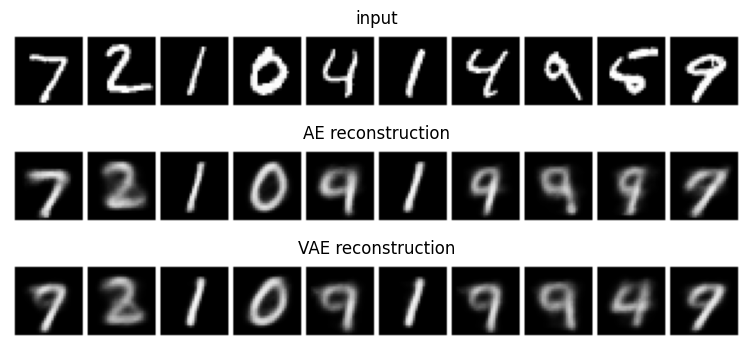

In [ ]:
x_test, y_test = next(iter(test_loader))
x_flat = x_test.view(-1, X_DIM).to(DEVICE)
with torch.no_grad():
    ae_hat = ae(x_flat)[0]
    vae_mean = vae.encoder(x_flat)[0]
    vae_hat = vae.decoder(vae_mean)          # 평가 시엔 샘플링 없이 μ 사용

fig, axes = plt.subplots(3, 1, figsize=(10, 3.6))
show_grid(x_test[:10], title="input", ax=axes[0])
show_grid(ae_hat[:10], title="AE reconstruction", ax=axes[1])
show_grid(vae_hat[:10], title="VAE reconstruction", ax=axes[2])
plt.tight_layout(); plt.show()

784 → **2개 숫자** → 784 로 복원한 것치고는 꽤 잘 복원됨. 대신 흐릿함 (VAE의 대표적 특징).

## 3. Latent space 들여다보기

### 3-1. test 이미지 10,000장을 2차원 latent에 찍어보기

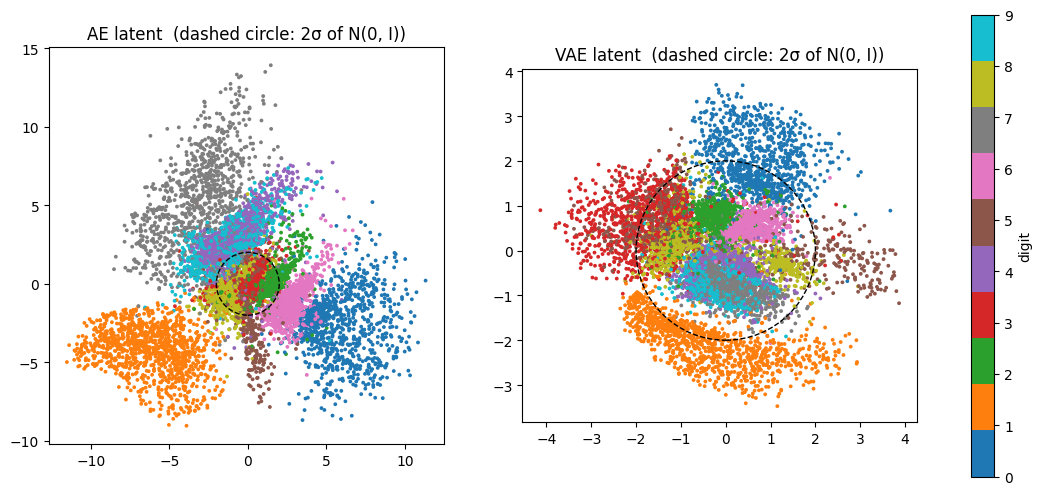

In [ ]:
@torch.no_grad()
def encode_all(model, loader):
    zs, ys = [], []
    for x, y in loader:
        zs.append(model.encoder(x.view(-1, X_DIM).to(DEVICE))[0].cpu()); ys.append(y)
    return torch.cat(zs), torch.cat(ys)

z_ae, labels = encode_all(ae, test_loader)
z_vae, _ = encode_all(vae, test_loader)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, z, name in [(axes[0], z_ae, "AE latent"), (axes[1], z_vae, "VAE latent")]:
    sc = ax.scatter(z[:, 0], z[:, 1], c=labels, cmap="tab10", s=3)
    ax.add_patch(plt.Circle((0, 0), 2, fill=False, ls="--", color="k"))   # N(0,I)의 약 2σ 범위
    ax.set_title(f"{name}  (dashed circle: 2σ of N(0, I))"); ax.set_aspect("equal")
plt.colorbar(sc, ax=axes, ticks=range(10), label="digit")
plt.show()

- 두 모델 모두 **label을 전혀 안 줬는데** 같은 숫자끼리 뭉침 → 비지도 학습으로 의미 있는 표현을 배움
- AE: 값의 범위가 제멋대로이고 군집 사이에 빈 공간이 큼
- VAE: KL 항 덕분에 원점 근처(점선 원)에 빈틈 없이 모여 있음 → **$N(0, I)$ 에서 뽑은 $z$ 가 대부분 "의미 있는" 위치에 떨어짐**

### 3-2. 랜덤 z ~ N(0, I) 로 생성해보기

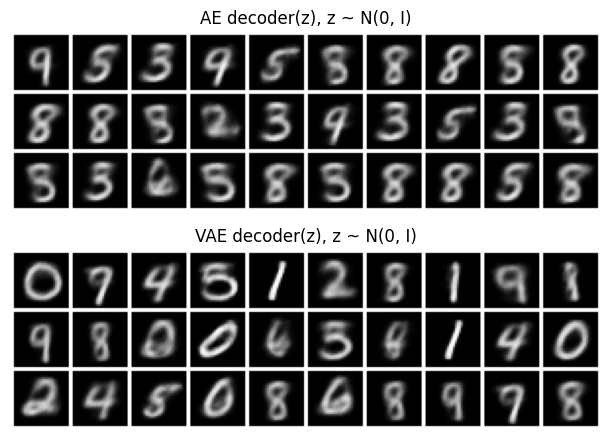

In [ ]:
torch.manual_seed(1)
z = torch.randn(30, LATENT_DIM, device=DEVICE)       # 표준정규분포에서 z 30개 샘플링
with torch.no_grad():
    gen_ae, gen_vae = ae.decoder(z), vae.decoder(z)   # encoder 없이 decoder만 사용

fig, axes = plt.subplots(2, 1, figsize=(10, 4.5))
show_grid(gen_ae, title="AE decoder(z), z ~ N(0, I)", ax=axes[0])
show_grid(gen_vae, title="VAE decoder(z), z ~ N(0, I)", ax=axes[1])
plt.tight_layout(); plt.show()

- AE: 숫자처럼 보이긴 하지만 **특정 숫자만 반복됨** → 3-1 산점도에서 원점 근처에 있던 숫자들만 나옴. 나머지 숫자는 N(0, I) 바깥에 있어서 랜덤 샘플링으로는 거의 안 뽑힘
- VAE는 다양한 숫자가 나옴 (encoder 없이 prior에서 샘플링 → decoder)

### 3-3. Latent space 지도 (2D manifold)
latent 공간을 격자로 훑으면서 decode → 숫자가 공간에 어떻게 배치됐는지 한눈에 봄

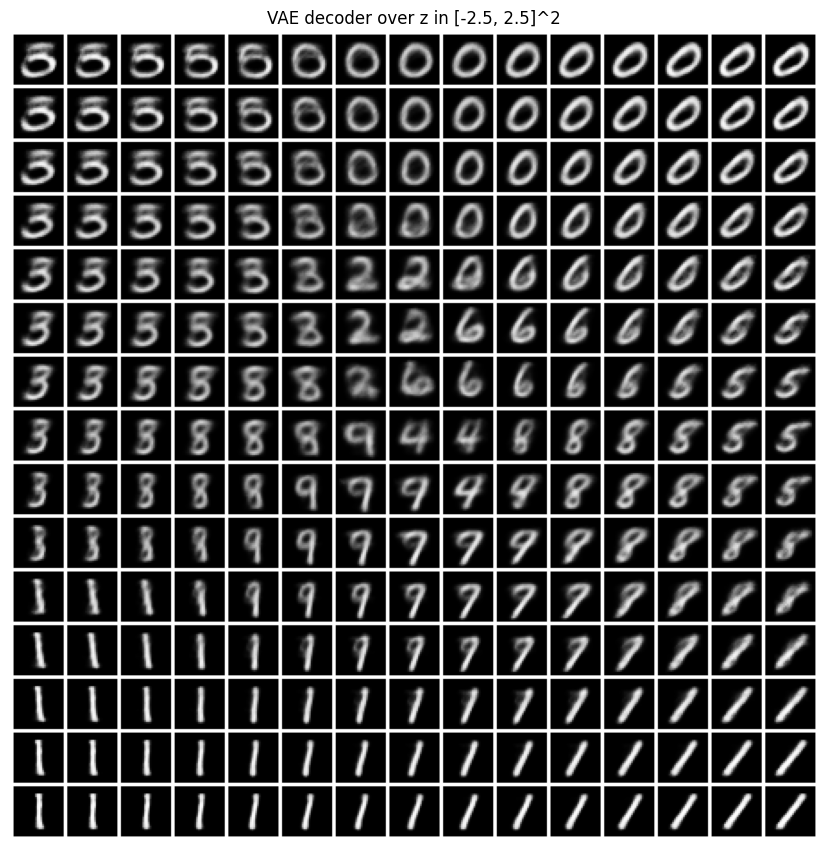

In [ ]:
n = 15
grid_vals = torch.linspace(-2.5, 2.5, n)
zz = torch.stack(torch.meshgrid(grid_vals, -grid_vals, indexing="xy"), -1).view(-1, 2)   # 위쪽이 +y 되도록
with torch.no_grad():
    manifold = vae.decoder(zz.to(DEVICE)) if LATENT_DIM == 2 else None

if manifold is not None:
    show_grid(manifold, nrow=n, title="VAE decoder over z in [-2.5, 2.5]^2"); plt.show()

인접한 칸끼리 숫자가 **부드럽게 변함**. latent 공간에서 가까우면 이미지도 비슷함 → 3-1 산점도의 색 배치와 비교해보기.

### 3-4. 두 이미지 사이 보간 (interpolation)

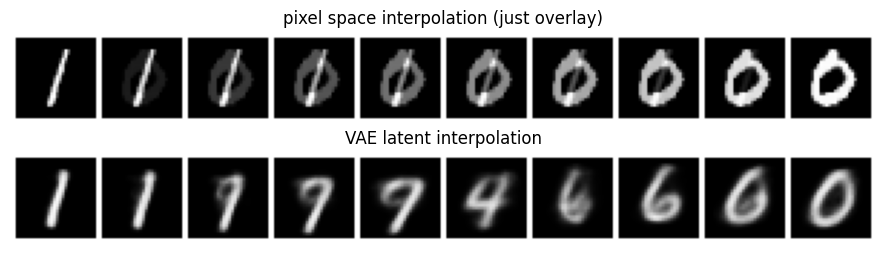

In [ ]:
a, b = x_flat[y_test == 1][0], x_flat[y_test == 0][0]       # 숫자 1과 0
with torch.no_grad():
    za, zb = vae.encoder(a[None])[0], vae.encoder(b[None])[0]
    t = torch.linspace(0, 1, 10, device=DEVICE).view(-1, 1)
    interp = vae.decoder((1 - t) * za + t * zb)             # latent에서 직선으로 이동
    pixel_interp = (1 - t) * a + t * b                      # 비교: 픽셀 공간에서 직선 이동

fig, axes = plt.subplots(2, 1, figsize=(10, 2.6))
show_grid(pixel_interp, title="pixel space interpolation (just overlay)", ax=axes[0])
show_grid(interp, title="VAE latent interpolation", ax=axes[1])
plt.tight_layout(); plt.show()

픽셀 공간 보간은 두 이미지를 겹쳐 놓은 것일 뿐이지만, latent 보간은 **"그럴듯한 숫자"를 거쳐서** 변함 → latent space가 데이터의 구조를 담고 있음.

> **β-VAE**: `loss_fn` 의 `beta` 를 1보다 크게 하면 latent가 더 정돈되고(더 원형, 해석 쉬움) 재구성은 흐려짐. 작게 하면 AE에 가까워짐. `train_model(True, beta=4.0)` 으로 실험해볼 수 있음.

## 4. 활용: 이상 탐지 (Anomaly detection)

**아이디어**: 정상 데이터로만 학습한 VAE는 정상 데이터는 잘 복원하지만, **처음 보는 유형의 데이터는 잘 복원 못함** → 재구성 오차가 크면 이상치로 판단.

- 금융 예시: 정상 거래 패턴으로만 학습 → 복원 오차가 큰 거래 = 이상 거래(사기) 후보
- 장점: **이상치 label이 필요 없음** (사기 사례는 드물고 형태도 계속 바뀜)

여기선 MNIST(정상)로 학습한 VAE에 **Fashion-MNIST(옷 이미지, 이상치)** 를 넣어봄.

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 200kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.8MB/s]


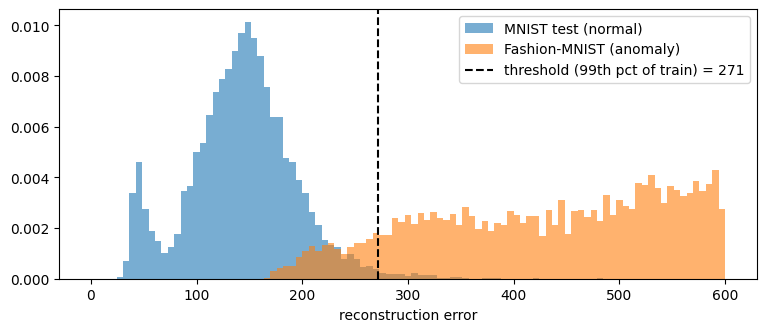

정상 데이터 오탐률 (False positive): 1.2%
이상치 탐지율     (Recall)        : 95.2%


In [ ]:
fashion = dsets.FashionMNIST("./data", train=False, download=True, transform=transforms.ToTensor())
fashion_loader = DataLoader(fashion, batch_size=1000, shuffle=False, num_workers=2)

@torch.no_grad()
def anomaly_score(model, loader):
    # 이미지별 재구성 오차 (BCE 합). 평가 시엔 샘플링 없이 μ 사용
    scores = []
    for x, _ in loader:
        x = x.view(-1, X_DIM).to(DEVICE)
        x_hat = model.decoder(model.encoder(x)[0])
        scores.append(F.binary_cross_entropy(x_hat, x, reduction="none").sum(1).cpu())
    return torch.cat(scores)

score_train = anomaly_score(vae, DataLoader(train_data, batch_size=1000, num_workers=2))
score_normal = anomaly_score(vae, test_loader)
score_anomal = anomaly_score(vae, fashion_loader)

# threshold: 정상 학습 데이터 오차의 99 percentile → 정상의 약 1%만 이상치로 오탐하도록 설정
threshold = torch.quantile(score_train, 0.99).item()

plt.figure(figsize=(9, 3.5))
bins = np.linspace(0, 600, 100)
plt.hist(score_normal, bins=bins, alpha=0.6, density=True, label="MNIST test (normal)")
plt.hist(score_anomal, bins=bins, alpha=0.6, density=True, label="Fashion-MNIST (anomaly)")
plt.axvline(threshold, color="k", ls="--", label=f"threshold (99th pct of train) = {threshold:.0f}")
plt.xlabel("reconstruction error"); plt.legend(); plt.show()

print(f"정상 데이터 오탐률 (False positive): {(score_normal > threshold).float().mean()*100:.1f}%")
print(f"이상치 탐지율     (Recall)        : {(score_anomal > threshold).float().mean()*100:.1f}%")

### 정상 데이터 안의 "이상한" 샘플 찾기
같은 방법으로 **MNIST test 안에서 재구성 오차가 가장 큰 샘플** 을 보면, 데이터 정제(data cleaning)에도 활용할 수 있음.

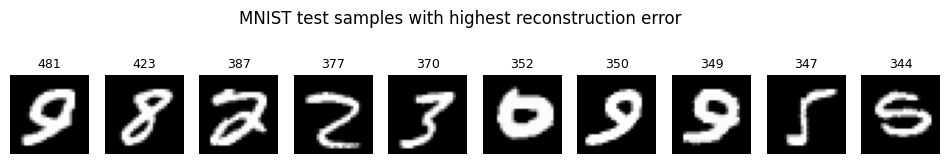

In [ ]:
top = score_normal.argsort(descending=True)[:10]
fig, axes = plt.subplots(1, 10, figsize=(12, 1.8))
for ax, i in zip(axes, top):
    ax.imshow(test_data[i][0][0], cmap="gray"); ax.set_title(f"{score_normal[i]:.0f}", fontsize=9); ax.axis("off")
plt.suptitle("MNIST test samples with highest reconstruction error", y=1.08); plt.show()

**Notes**
- threshold는 풀고자 하는 task 에 맞추어 정함: 오탐(정상 거래 차단)의 비용 vs 미탐(사기 통과)의 비용
- 재구성 오차가 항상 잘 동작하진 않음: 단순한 이상치(예: 빈 이미지)는 오히려 복원이 잘돼서 못 잡는 경우가 알려져 있음 → 반드시 실제 이상 사례로 검증
- 정상 데이터에 이상치가 섞여 있으면 그것까지 "정상"으로 학습함 → 학습 데이터 정제가 중요

---
## Discussion
1. latent를 2차원이 아니라 16차원으로 늘리면 재구성, 생성, 이상 탐지 성능은 각각 어떻게 달라질까?
   - 정보를 더 담을 수 있어 재구성·생성은 더 선명해짐. 이상 탐지는 이상치까지 잘 복원해버려서 오히려 나빠질 수도 있음.
2. β를 키우거나 줄이면 3-1의 latent 산점도는 어떻게 바뀔까?
   - β↑ → N(0, I) 쪽으로 더 강하게 모여 원형에 가까워지고 재구성은 흐려짐. β↓ → AE처럼 넓게 퍼지고 재구성은 선명해짐.

## Summary
- AE: 압축/복원. latent에 제약이 없어 생성에 쓰기 어려움
- VAE: latent를 $N(0, I)$ 에 맞춰 정돈 → **decoder만으로 생성 가능**, encoder로 **데이터를 의미 있는 저차원 벡터로 변환** 가능
- 활용: 이상 탐지, 데이터 압축/표현 학습, 그리고 **Stable Diffusion 내부의 이미지 압축기(VAE)** 로도 쓰임